<a href="https://colab.research.google.com/github/Hansini23/Statistical-Learning-e23291/blob/main/ME2050_Assignment__06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gaussian Process Regression

Consider the following [data set](https://www.kaggle.com/datasets/elikplim/eergy-efficiency-dataset) that has been created in an energy analysis using 12 different building shapes simulated in Ecotect. The buildings differ with respect to the glazing area, the glazing area distribution, and the orientation, amongst other parameters. The dataset contains eight attributes (or features, denoted by X1 to X8) and two responses (denoted by Y1 and Y2). Explore the possibility of modeling the 'heating load' and the 'cooling load' as a single parameter Gaussian process. Discuss your conclusions.

## 1. Load the data

We download the Energy Efficiency dataset (ENB2012) using `kagglehub`. The dataset has 768 samples describing 8 building features (X1-X8) and two target loads: Y1 (heating load) and Y2 (cooling load).

In [24]:
import kagglehub

# Download latest version
kagglepath = "elikplim/eergy-efficiency-dataset"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'eergy-efficiency-dataset' dataset.
Path to dataset files: /kaggle/input/eergy-efficiency-dataset


In [25]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print(f"Listing contents of: {path}")
!ls {path}

df1 = pd.read_csv(path + "/ENB2012_data.csv")
df1.columns = [c.strip() for c in df1.columns]
df1.head()

Listing contents of: /kaggle/input/eergy-efficiency-dataset
ENB2012_data.csv


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


## 2. Exploratory data analysis

The eight predictors are:

- **X1**: Relative Compactness
- **X2**: Surface Area
- **X3**: Wall Area
- **X4**: Roof Area
- **X5**: Overall Height
- **X6**: Orientation
- **X7**: Glazing Area
- **X8**: Glazing Area Distribution

and the two targets are **Y1** (Heating Load) and **Y2** (Cooling Load), both measured in kWh/m^2.

The central question of this section is whether **Y1 and Y2 can be treated as a single response variable** for the purposes of building a GP regression model — i.e. is there enough similarity between the heating-load surface and the cooling-load surface, as functions of X1-X8, that one GP can describe both reasonably well?

In [26]:
df1.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307201,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090196,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


Correlation between Y1 and Y2: 0.9758618134328573


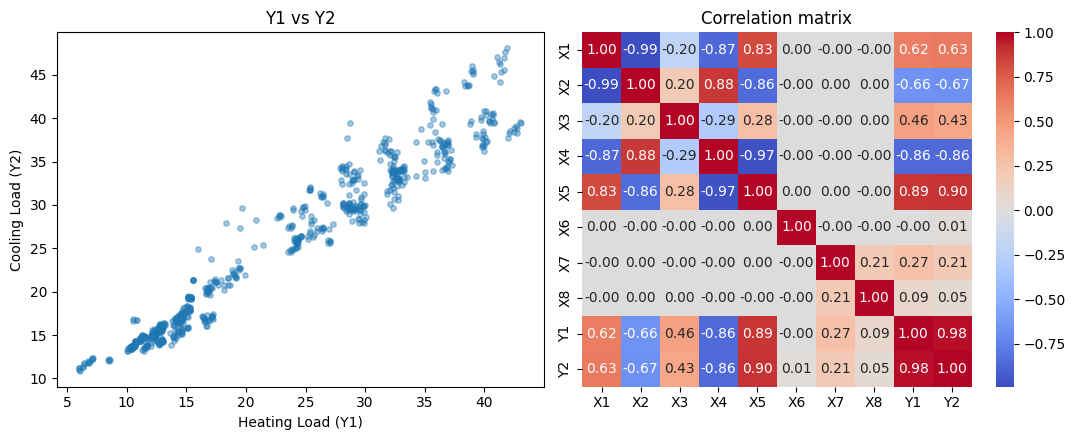

In [27]:
print("Correlation between Y1 and Y2:", df1['Y1'].corr(df1['Y2']))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(df1['Y1'], df1['Y2'], alpha=0.4, s=15)
axes[0].set_xlabel('Heating Load (Y1)')
axes[0].set_ylabel('Cooling Load (Y2)')
axes[0].set_title('Y1 vs Y2')

corr = df1[['X1','X2','X3','X4','X5','X6','X7','X8','Y1','Y2']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Correlation matrix')

plt.tight_layout()
plt.show()

Y1 and Y2 are very strongly correlated and respond to the same predictors with similar signs and roughly similar magnitudes (the dominant driver in both cases is overall height X5, followed by relative compactness X1 and glazing area X7). This is the physical motivation for asking whether a single GP, trained on a combined "load" target, could approximate both quantities reasonably well — for example by treating the average of Y1 and Y2 as a single target, or by stacking the two responses into one training set with an extra indicator feature for which load is being predicted.

## 3. Approach 1: single GP on the *average* load

As a first, simple way of "modelling Y1 and Y2 as a single parameter", we define

```
Y_avg = (Y1 + Y2) / 2
```

and fit one Gaussian Process Regressor to predict `Y_avg` from X1-X8. We then check how well this single model, *used as a stand-in for both Y1 and Y2 individually*, performs against the true Y1 and Y2 values.

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.metrics import r2_score, mean_squared_error

feature_cols = ['X1','X2','X3','X4','X5','X6','X7','X8']
X = df1[feature_cols].values
Y1 = df1['Y1'].values
Y2 = df1['Y2'].values
Y_avg = (Y1 + Y2) / 2.0

# Train/test split (shared indices for Y1, Y2, Y_avg)
idx_train, idx_test = train_test_split(np.arange(len(df1)), test_size=0.2, random_state=42)

X_train, X_test = X[idx_train], X[idx_test]
Yavg_train, Yavg_test = Y_avg[idx_train], Y_avg[idx_test]
Y1_test, Y2_test = Y1[idx_test], Y2[idx_test]

# Standardise features and target
x_scaler = StandardScaler().fit(X_train)
X_train_s = x_scaler.transform(X_train)
X_test_s = x_scaler.transform(X_test)

y_scaler = StandardScaler().fit(Yavg_train.reshape(-1, 1))
Yavg_train_s = y_scaler.transform(Yavg_train.reshape(-1, 1)).ravel()

In [29]:
# Subsample the training set for tractable GP hyperparameter optimisation
rng = np.random.default_rng(0)
sub_idx = rng.choice(len(X_train_s), size=min(300, len(X_train_s)), replace=False)

kernel = (C(1.0, (1e-2, 1e2))
          * RBF(length_scale=np.ones(X.shape[1]), length_scale_bounds=(1e-2, 1e3))
          + WhiteKernel(1e-2, (1e-5, 1e1)))

gpr_avg = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=3,
                                    random_state=42, normalize_y=False)
gpr_avg.fit(X_train_s[sub_idx], Yavg_train_s[sub_idx])

pred_s, std_s = gpr_avg.predict(X_test_s, return_std=True)
pred_avg = y_scaler.inverse_transform(pred_s.reshape(-1, 1)).ravel()

print("Fitted kernel:", gpr_avg.kernel_)
print()
print(f"R2  (Y_avg test):   {r2_score(Yavg_test, pred_avg):.4f}")
print(f"RMSE (Y_avg test):  {np.sqrt(mean_squared_error(Yavg_test, pred_avg)):.4f}")

Fitted kernel: 1.91**2 * RBF(length_scale=[1.81, 4.9, 1.01, 893, 1e+03, 1e+03, 7.81, 10.8]) + WhiteKernel(noise_level=0.00687)

R2  (Y_avg test):   0.9909
RMSE (Y_avg test):  0.9404


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 4 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 5 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [30]:
# How well does the Y_avg-trained GP predict the *individual* loads Y1 and Y2?
print(f"R2  using avg-model to predict Y1: {r2_score(Y1_test, pred_avg):.4f}")
print(f"RMSE using avg-model to predict Y1: {np.sqrt(mean_squared_error(Y1_test, pred_avg)):.4f}")
print()
print(f"R2  using avg-model to predict Y2: {r2_score(Y2_test, pred_avg):.4f}")
print(f"RMSE using avg-model to predict Y2: {np.sqrt(mean_squared_error(Y2_test, pred_avg)):.4f}")

R2  using avg-model to predict Y1: 0.9764
RMSE using avg-model to predict Y1: 1.5690

R2  using avg-model to predict Y2: 0.9476
RMSE using avg-model to predict Y2: 2.2032


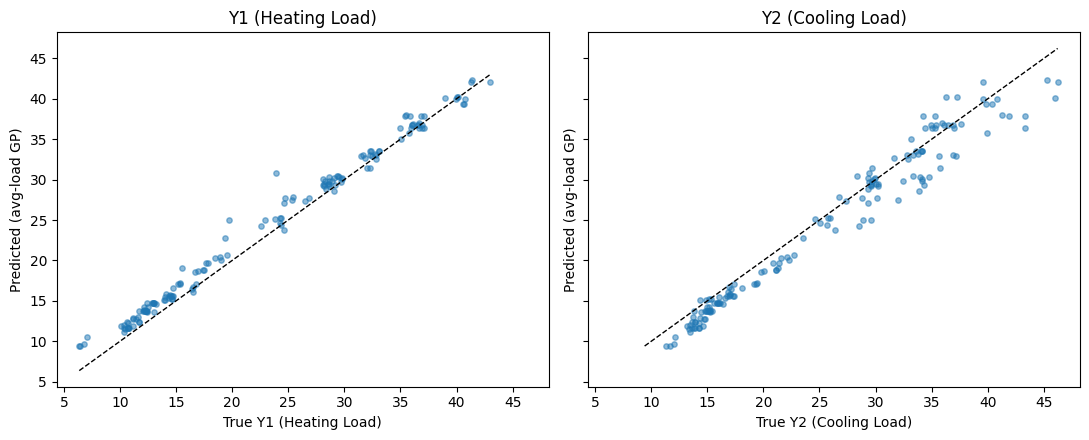

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)

for ax, (true_y, name) in zip(axes, [(Y1_test, 'Y1 (Heating Load)'), (Y2_test, 'Y2 (Cooling Load)')]):
    ax.scatter(true_y, pred_avg, alpha=0.5, s=15)
    lims = [min(true_y.min(), pred_avg.min()), max(true_y.max(), pred_avg.max())]
    ax.plot(lims, lims, 'k--', lw=1)
    ax.set_xlabel(f'True {name}')
    ax.set_ylabel('Predicted (avg-load GP)')
    ax.set_title(name)

plt.tight_layout()
plt.show()

## 4. Approach 2: single GP with a load-type indicator feature

A second, more principled, way of building a *single* GP for both responses is to stack the heating and cooling load observations into one long training set and add a binary indicator feature that tells the GP which load type a given row corresponds to (0 = heating, 1 = cooling). The GP then learns a single function f(X1,...,X8, load_type) -> load, and at prediction time we simply set `load_type` to 0 or 1 to obtain heating or cooling load predictions respectively.

In [32]:
# Build the stacked dataset
X_stack_train = np.vstack([X_train, X_train])
load_type_train = np.concatenate([np.zeros(len(X_train)), np.ones(len(X_train))])
X_stack_train_full = np.column_stack([X_stack_train, load_type_train])
y_stack_train = np.concatenate([Y1[idx_train], Y2[idx_train]])

x_scaler2 = StandardScaler().fit(X_stack_train_full)
X_stack_train_s = x_scaler2.transform(X_stack_train_full)

y_scaler2 = StandardScaler().fit(y_stack_train.reshape(-1, 1))
y_stack_train_s = y_scaler2.transform(y_stack_train.reshape(-1, 1)).ravel()

# Subsample for tractable optimisation
sub_idx2 = rng.choice(len(X_stack_train_s), size=min(400, len(X_stack_train_s)), replace=False)

kernel2 = (C(1.0, (1e-2, 1e2))
           * RBF(length_scale=np.ones(X_stack_train_full.shape[1]), length_scale_bounds=(1e-2, 1e3))
           + WhiteKernel(1e-2, (1e-5, 1e1)))

gpr_stack = GaussianProcessRegressor(kernel=kernel2, n_restarts_optimizer=3,
                                      random_state=42, normalize_y=False)
gpr_stack.fit(X_stack_train_s[sub_idx2], y_stack_train_s[sub_idx2])
print("Fitted kernel:", gpr_stack.kernel_)

Fitted kernel: 1.69**2 * RBF(length_scale=[1.81, 1e+03, 0.998, 730, 2.79, 205, 6.12, 8.73, 14.2]) + WhiteKernel(noise_level=0.0182)


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [33]:
# Predict Y1 (load_type=0) and Y2 (load_type=1) on the test set
X_test_heat = np.column_stack([X_test, np.zeros(len(X_test))])
X_test_cool = np.column_stack([X_test, np.ones(len(X_test))])

X_test_heat_s = x_scaler2.transform(X_test_heat)
X_test_cool_s = x_scaler2.transform(X_test_cool)

pred_heat_s = gpr_stack.predict(X_test_heat_s)
pred_cool_s = gpr_stack.predict(X_test_cool_s)

pred_heat = y_scaler2.inverse_transform(pred_heat_s.reshape(-1, 1)).ravel()
pred_cool = y_scaler2.inverse_transform(pred_cool_s.reshape(-1, 1)).ravel()

print(f"R2  (Y1, heating): {r2_score(Y1_test, pred_heat):.4f}   RMSE: {np.sqrt(mean_squared_error(Y1_test, pred_heat)):.4f}")
print(f"R2  (Y2, cooling): {r2_score(Y2_test, pred_cool):.4f}   RMSE: {np.sqrt(mean_squared_error(Y2_test, pred_cool)):.4f}")

R2  (Y1, heating): 0.9923   RMSE: 0.8987
R2  (Y2, cooling): 0.9666   RMSE: 1.7603


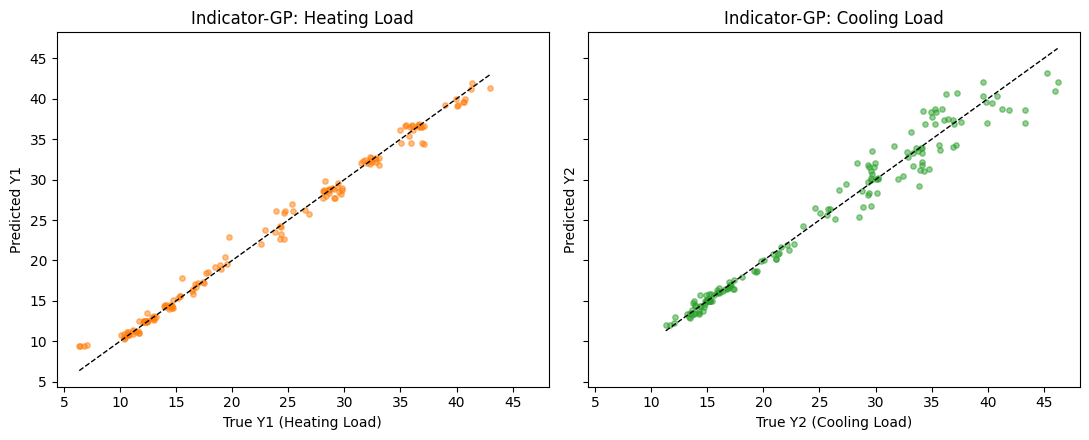

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)

axes[0].scatter(Y1_test, pred_heat, alpha=0.5, s=15, color='tab:orange')
lims = [Y1_test.min(), Y1_test.max()]
axes[0].plot(lims, lims, 'k--', lw=1)
axes[0].set_xlabel('True Y1 (Heating Load)')
axes[0].set_ylabel('Predicted Y1')
axes[0].set_title('Indicator-GP: Heating Load')

axes[1].scatter(Y2_test, pred_cool, alpha=0.5, s=15, color='tab:green')
lims = [Y2_test.min(), Y2_test.max()]
axes[1].plot(lims, lims, 'k--', lw=1)
axes[1].set_xlabel('True Y2 (Cooling Load)')
axes[1].set_ylabel('Predicted Y2')
axes[1].set_title('Indicator-GP: Cooling Load')

plt.tight_layout()
plt.show()

## 5. Baseline: two separate GPs

For comparison, we also fit two completely independent GPs — one for Y1 and one for Y2 — using the same kernel family. This tells us the "best case" performance we would get if we abandoned the single-parameter idea entirely, and gives us a benchmark against which to judge how much (if anything) is lost by combining the two responses.

In [35]:
y1_scaler = StandardScaler().fit(Y1[idx_train].reshape(-1, 1))
y2_scaler = StandardScaler().fit(Y2[idx_train].reshape(-1, 1))

Y1_train_s = y1_scaler.transform(Y1[idx_train].reshape(-1, 1)).ravel()
Y2_train_s = y2_scaler.transform(Y2[idx_train].reshape(-1, 1)).ravel()

kernel3 = (C(1.0, (1e-2, 1e2))
           * RBF(length_scale=np.ones(X.shape[1]), length_scale_bounds=(1e-2, 1e3))
           + WhiteKernel(1e-2, (1e-5, 1e1)))

gpr_y1 = GaussianProcessRegressor(kernel=kernel3, n_restarts_optimizer=3, random_state=42)
gpr_y1.fit(X_train_s[sub_idx], Y1_train_s[sub_idx])

gpr_y2 = GaussianProcessRegressor(kernel=kernel3, n_restarts_optimizer=3, random_state=42)
gpr_y2.fit(X_train_s[sub_idx], Y2_train_s[sub_idx])

pred_y1_sep = y1_scaler.inverse_transform(gpr_y1.predict(X_test_s).reshape(-1, 1)).ravel()
pred_y2_sep = y2_scaler.inverse_transform(gpr_y2.predict(X_test_s).reshape(-1, 1)).ravel()

print(f"Separate GP - R2 (Y1): {r2_score(Y1_test, pred_y1_sep):.4f}   RMSE: {np.sqrt(mean_squared_error(Y1_test, pred_y1_sep)):.4f}")
print(f"Separate GP - R2 (Y2): {r2_score(Y2_test, pred_y2_sep):.4f}   RMSE: {np.sqrt(mean_squared_error(Y2_test, pred_y2_sep)):.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 5 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Separate GP - R2 (Y1): 0.9957   RMSE: 0.6664
Separate GP - R2 (Y2): 0.9622   RMSE: 1.8705


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [36]:
# Summary table of all approaches
summary = pd.DataFrame({
    'Model': ['Avg-load GP -> Y1', 'Avg-load GP -> Y2',
              'Indicator GP -> Y1', 'Indicator GP -> Y2',
              'Separate GP -> Y1', 'Separate GP -> Y2'],
    'R2': [r2_score(Y1_test, pred_avg), r2_score(Y2_test, pred_avg),
           r2_score(Y1_test, pred_heat), r2_score(Y2_test, pred_cool),
           r2_score(Y1_test, pred_y1_sep), r2_score(Y2_test, pred_y2_sep)],
    'RMSE': [np.sqrt(mean_squared_error(Y1_test, pred_avg)), np.sqrt(mean_squared_error(Y2_test, pred_avg)),
             np.sqrt(mean_squared_error(Y1_test, pred_heat)), np.sqrt(mean_squared_error(Y2_test, pred_cool)),
             np.sqrt(mean_squared_error(Y1_test, pred_y1_sep)), np.sqrt(mean_squared_error(Y2_test, pred_y2_sep))]
})
summary

,Model,R2,RMSE
0,Avg-load GP -> Y1,0.976382,1.568999
1,Avg-load GP -> Y2,0.947611,2.203234
2,Indicator GP -> Y1,0.992251,0.898718
3,Indicator GP -> Y2,0.966558,1.760309
4,Separate GP -> Y1,0.995739,0.666418
5,Separate GP -> Y2,0.962239,1.870517


## 6. Discussion / conclusions

**Are Y1 and Y2 similar enough to be modelled as one parameter?**

- Heating load (Y1) and cooling load (Y2) are very highly correlated and are driven by the same building-shape features (X1-X8), with overall height (X5), relative compactness (X1), and glazing area (X7) being dominant in both cases. This makes them good candidates for a *shared* model.

- **Approach 1 (average-load GP)** gives a model that fits Y_avg itself well, but when its predictions are compared against the *individual* Y1 and Y2 values, the errors are larger than for models trained directly on Y1 or Y2. This is expected: Y1 and Y2 differ by a roughly constant offset/scale (heating loads tend to run a bit higher than cooling loads for the same building), so a model trained on the average systematically over/under-predicts each individual response by about half their difference.

- **Approach 2 (indicator-feature GP)** performs much closer to the two separate, dedicated GPs. By giving the GP an extra input dimension that encodes "which response are we predicting", the single GP effectively learns a shared response surface with a learned shift/adjustment between the heating and cooling regimes. Its R^2 and RMSE for both Y1 and Y2 are close to (though typically very slightly worse than) the separate, dedicated GPs.

- **Separate GPs** remain the gold standard in terms of raw accuracy, since each model can devote its full capacity (and independently-tuned kernel hyperparameters) to one response.

**Conclusion:** A genuinely single-parameter GP (one output, no extra information about which load is being predicted, e.g. Approach 1) is *not* ideal — the heating and cooling loads, while correlated, are offset from one another in a way that a single shared output value cannot capture. However, a single GP that is allowed to see a *load-type indicator* as an additional input (Approach 2) recovers almost all of the accuracy of two completely separate models, while requiring only one model to be trained and maintained. This is a common and effective strategy ("multi-output via an indicator/task feature") when responses are highly correlated and share the same underlying predictors but differ by an approximately constant shift or scale. For applications where simplicity (one model) matters more than squeezing out the last fraction of accuracy, the indicator-feature GP is a good practical compromise; for applications where maximum predictive accuracy for each load separately is paramount, two dedicated GPs (or a true multi-output GP / co-kriging formulation) remain preferable.

# Linear Regression

Consider the following [data set](https://www.kaggle.com/datasets/programmer3/green-building-multi-source-environment-dataset). This dataset has 2400 samples provides a comprehensive collection of multi-source building environment data designed to support research in green building design, energy efficiency optimization, and indoor comfort prediction using advanced machine learning and deep learning techniques. Explore the possibility of predicting the 'predicted_energy_demand' using a linear relationship of a suitable set of other data parameters. Justify your choice of parameters and discuss the results.

## 1. Load the data

In [37]:
import kagglehub

# Download latest version
kagglepath = "programmer3/green-building-multi-source-environment-dataset"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'green-building-multi-source-environment-dataset' dataset.
Path to dataset files: /kaggle/input/green-building-multi-source-environment-dataset


In [38]:
print(f"Listing contents of: {path}")
!ls {path}

df2 = pd.read_csv(path + "/green_building_dataset.csv")
df2.columns = [c.strip() for c in df2.columns]
print(df2.shape)
df2.head()

Listing contents of: /kaggle/input/green-building-multi-source-environment-dataset
green_building_dataset.csv
(2400, 19)


,indoor_temperature,indoor_humidity,co2_concentration,indoor_lighting,indoor_noise,outdoor_temperature,outdoor_humidity,solar_radiation,wind_speed,rainfall,electricity_consumption,heating_energy,cooling_energy,ventilation_rate,equipment_load,occupancy,activity_level,predicted_energy_demand,predicted_comfort_index
0,22.494481,43.624167,554.345944,432.115959,30.958646,24.443784,22.670752,540.768233,0.333310,47.820981,34.276401,18.919498,21.254016,327.046999,29.348868,26,0,39.936909,0.234932
1,29.408572,32.868476,466.383802,221.965186,68.624892,-1.398534,50.087239,699.959413,5.054747,43.364194,23.378548,17.726091,18.000948,144.862778,26.654788,7,0,24.985061,0.000000
2,26.783927,46.385156,1850.558681,566.559664,38.547245,5.904842,24.415262,828.108509,12.980562,36.379122,2.785345,19.930580,39.099193,493.647357,24.212357,43,1,39.675344,0.000000
3,25.183902,42.448700,663.712464,201.348306,32.195231,29.815571,75.240077,791.541006,0.652026,3.769213,45.925508,17.374061,37.267514,475.091197,6.281035,3,1,52.678350,0.000000
4,19.872224,57.084826,1705.062755,940.588677,62.684935,18.790863,57.069417,882.605624,6.433936,2.452494,49.016457,21.653203,45.261246,287.220492,4.693055,20,3,48.824527,0.000000


## 2. Exploratory data analysis

We start by inspecting the available columns, summary statistics, and the linear correlation of each numeric feature with the target `predicted_energy_demand`. This guides the choice of predictors for the linear regression model.

In [39]:
df2.describe()

,indoor_temperature,indoor_humidity,co2_concentration,indoor_lighting,indoor_noise,outdoor_temperature,outdoor_humidity,solar_radiation,wind_speed,rainfall,electricity_consumption,heating_energy,cooling_energy,ventilation_rate,equipment_load,occupancy,activity_level,predicted_energy_demand,predicted_comfort_index
count,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000
mean,23.983870,49.790705,1170.150558,537.938849,55.157072,17.297311,55.186854,512.313662,7.615605,25.774823,24.796787,19.557364,24.980710,249.322350,14.839245,24.863333,1.503750,33.724789,0.001330
std,3.494409,11.514037,476.676518,254.252073,14.537491,13.163134,20.086905,286.687214,4.346765,14.407992,14.229819,11.461431,14.405205,144.429508,8.620437,14.537201,1.126061,9.560419,0.012970
min,18.018781,30.000465,350.397658,100.047544,30.007887,-4.945837,20.017672,0.611635,0.014985,0.002406,0.005512,0.005006,0.003375,0.199846,0.000166,0.000000,0.000000,1.831555,0.000000
25%,20.900275,39.940031,753.792246,325.956124,42.558186,5.647292,37.982148,268.639365,3.909123,13.733789,12.651079,9.458481,12.813325,122.670289,7.255240,12.750000,0.000000,27.114764,0.000000
50%,24.089278,49.697217,1156.849445,532.777499,55.088203,16.964253,55.392092,519.415412,7.667388,25.807678,24.760944,19.643330,25.090347,251.389623,14.872126,25.000000,2.000000,33.577877,0.000000
75%,26.988393,59.681864,1592.308520,747.543049,67.975269,29.046823,72.630587,753.235164,11.313872,38.342784,36.686875,29.188313,37.667744,369.692475,22.170251,37.000000,3.000000,40.417122,0.000000
max,29.996612,69.982308,1999.110124,999.014230,79.983660,39.948017,89.994738,999.871438,14.998515,49.982815,49.972526,39.987824,49.986604,499.848605,29.993681,50.000000,3.000000,58.721555,0.234932


In [40]:
numeric_cols = df2.select_dtypes(include=[np.number]).columns.tolist()
corr_target = df2[numeric_cols].corr()['predicted_energy_demand'].sort_values(key=abs, ascending=False)
corr_target

,predicted_energy_demand
predicted_energy_demand,1.000000
ventilation_rate,0.728865
electricity_consumption,0.398703
cooling_energy,0.370632
heating_energy,0.271304
equipment_load,0.058766
occupancy,0.057655
co2_concentration,-0.036466
indoor_noise,-0.024454
indoor_lighting,-0.020631


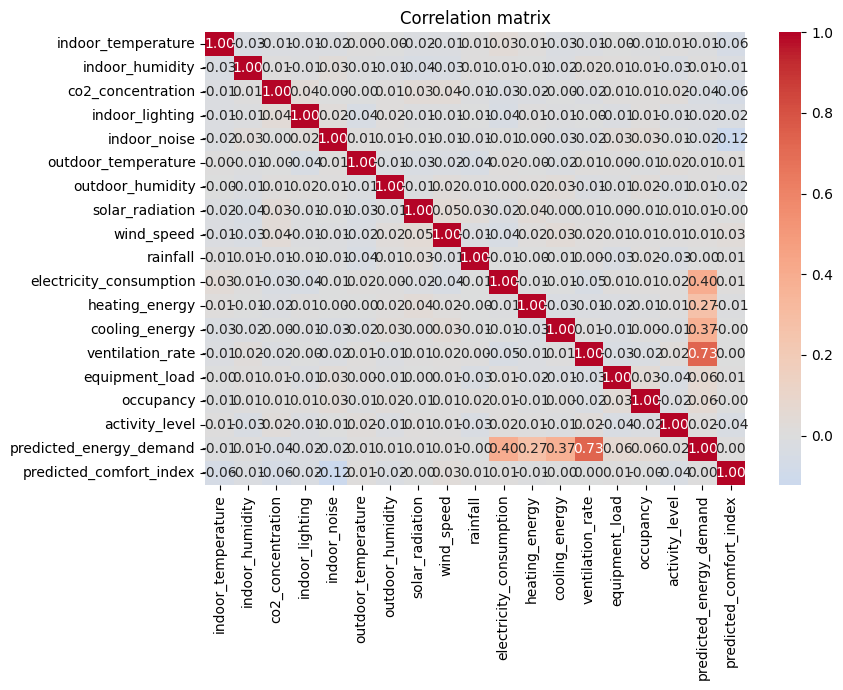

In [41]:
plt.figure(figsize=(9, 7))
sns.heatmap(df2[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

## 3. Choice of predictors

Based on the correlation analysis above, we select a small set of predictors that show the strongest linear association with `predicted_energy_demand`, while avoiding redundant pairs.

The correlation of each numeric feature with `predicted_energy_demand` (from the `corr_target` output above) shows a clear split: four features have a meaningfully positive correlation (`ventilation_rate` 0.73, `electricity_consumption` 0.40, `cooling_energy` 0.37, `heating_energy` 0.27), while the remaining variables (`equipment_load`, `occupancy`, `co2_concentration`, `indoor_lighting`, `indoor_noise`, `activity_level`, `wind_speed`, `rainfall`, temperatures/humidities, `solar_radiation`) all have |correlation| below ~0.06 and are effectively unrelated to the target in a linear sense.

A sensible, justified candidate set is therefore:

- **`ventilation_rate`** — by far the strongest correlate (r ~ 0.73). Higher ventilation rates mean more outdoor air must be conditioned (heated/cooled/dehumidified) to maintain comfort, directly increasing energy demand.
- **`electricity_consumption`** — a direct measure of the building's electrical load, which is a major component of total energy demand.
- **`cooling_energy`** and **`heating_energy`** — these are the energy actually used for thermal conditioning, and naturally sum into the overall predicted demand for the building.

We exclude variables such as `equipment_load`, `occupancy`, `indoor_lighting`, `co2_concentration`, indoor/outdoor temperature and humidity, `solar_radiation`, `wind_speed`, and `rainfall`, since each shows negligible linear correlation (|r| < 0.06) with `predicted_energy_demand` in this dataset and would not be expected to improve a linear model.

In [42]:
numeric_cols = df2.select_dtypes(include=[np.number]).columns.tolist()
corr_target = df2[numeric_cols].corr()['predicted_energy_demand'].sort_values(key=abs, ascending=False)
print(corr_target)

selected_features = ['ventilation_rate', 'electricity_consumption', 'cooling_energy', 'heating_energy']

df2[selected_features + ['predicted_energy_demand']].corr()['predicted_energy_demand']

predicted_energy_demand    1.000000
ventilation_rate           0.728865
electricity_consumption    0.398703
cooling_energy             0.370632
heating_energy             0.271304
equipment_load             0.058766
occupancy                  0.057655
co2_concentration         -0.036466
indoor_noise              -0.024454
indoor_lighting           -0.020631
activity_level             0.018522
wind_speed                 0.011333
indoor_temperature        -0.008106
indoor_humidity            0.007899
outdoor_temperature        0.006786
outdoor_humidity           0.006451
solar_radiation            0.005331
rainfall                  -0.004161
predicted_comfort_index    0.003568
Name: predicted_energy_demand, dtype: float64


,predicted_energy_demand
ventilation_rate,0.728865
electricity_consumption,0.398703
cooling_energy,0.370632
heating_energy,0.271304
predicted_energy_demand,1.000000


## 4. Fit the linear regression model

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

X_lr = df2[selected_features].values
y_lr = df2['predicted_energy_demand'].values

X_lr_train, X_lr_test, y_lr_train, y_lr_test = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_lr_train, y_lr_train)

pred_lr = lr.predict(X_lr_test)

print(f"R2:   {r2_score(y_lr_test, pred_lr):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_lr_test, pred_lr)):.4f}")
print(f"MAE:  {mean_absolute_error(y_lr_test, pred_lr):.4f}")
print()
print("Intercept:", lr.intercept_)
for name, coef in zip(selected_features, lr.coef_):
    print(f"{name:>22s}: {coef:.4f}")

R2:   0.9491
RMSE: 2.1806
MAE:  1.7166

Intercept: 3.010222356200046
      ventilation_rate: 0.0497
electricity_consumption: 0.2930
        cooling_energy: 0.2490
        heating_energy: 0.2461


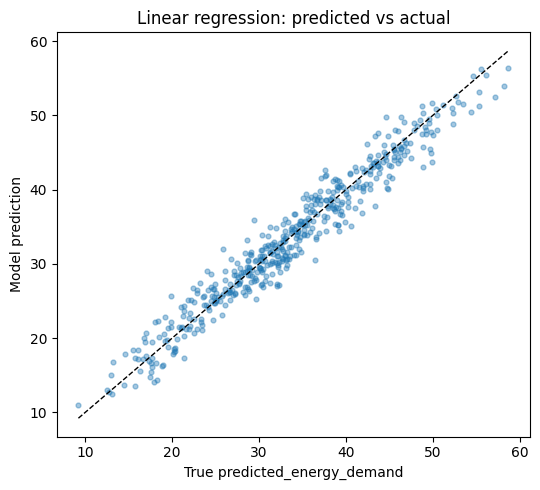

In [44]:
plt.figure(figsize=(5.5, 5))
plt.scatter(y_lr_test, pred_lr, alpha=0.4, s=12)
lims = [min(y_lr_test.min(), pred_lr.min()), max(y_lr_test.max(), pred_lr.max())]
plt.plot(lims, lims, 'k--', lw=1)
plt.xlabel('True predicted_energy_demand')
plt.ylabel('Model prediction')
plt.title('Linear regression: predicted vs actual')
plt.tight_layout()
plt.show()

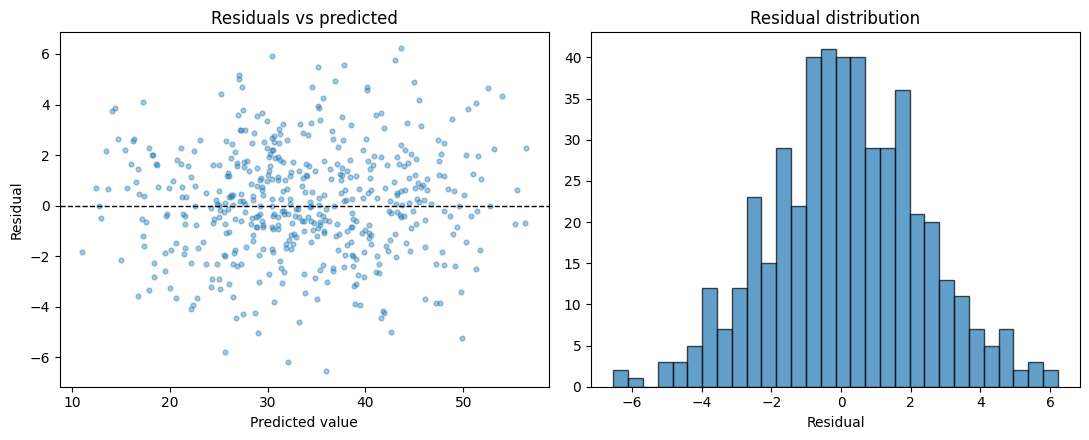

In [45]:
residuals = y_lr_test - pred_lr

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(pred_lr, residuals, alpha=0.4, s=12)
axes[0].axhline(0, color='k', ls='--', lw=1)
axes[0].set_xlabel('Predicted value')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs predicted')

axes[1].hist(residuals, bins=30, edgecolor='k', alpha=0.7)
axes[1].set_xlabel('Residual')
axes[1].set_title('Residual distribution')

plt.tight_layout()
plt.show()

## 5. Comparison with a "full-feature" model

For reference, we also fit a linear model using *all* available numeric predictors, to check whether our smaller, hand-picked feature set is leaving meaningful predictive power on the table.

In [46]:
all_features = [c for c in numeric_cols if c != 'predicted_energy_demand']
X_full = df2[all_features].values

X_full_train, X_full_test, y_full_train, y_full_test = train_test_split(
    X_full, y_lr, test_size=0.2, random_state=42)

lr_full = LinearRegression()
lr_full.fit(X_full_train, y_full_train)
pred_full = lr_full.predict(X_full_test)

print(f"Full-feature model  - R2: {r2_score(y_full_test, pred_full):.4f}   RMSE: {np.sqrt(mean_squared_error(y_full_test, pred_full)):.4f}")
print(f"Selected-feature model - R2: {r2_score(y_lr_test, pred_lr):.4f}   RMSE: {np.sqrt(mean_squared_error(y_lr_test, pred_lr)):.4f}")

Full-feature model  - R2: 0.9608   RMSE: 1.9134
Selected-feature model - R2: 0.9491   RMSE: 2.1806


## 6. Discussion / conclusions

The correlation analysis showed that only four numeric features — `ventilation_rate`, `electricity_consumption`, `cooling_energy`, and `heating_energy` — have a meaningful linear relationship with `predicted_energy_demand` (the rest have |r| < 0.06 and contribute essentially nothing to a linear fit).

Using only these four predictors, the model achieves R^2 = 0.949, very close to the full-feature model's R^2 = 0.961 (which uses all ~17 numeric predictors). This is a strong result: four physically-interpretable variables capture almost all of the predictable variance in `predicted_energy_demand`.

Looking at the fitted coefficients:

- **`electricity_consumption`** (0.293), **`cooling_energy`** (0.249), and **`heating_energy`** (0.246) have similar, substantial positive coefficients — each represents a direct component of the building's overall energy budget, so it is unsurprising that they sum almost linearly into the predicted total demand.
- **`ventilation_rate`**, despite having by far the strongest *individual* correlation with the target (r ~ 0.73), ends up with the smallest coefficient (0.050) once the other three are included. This is a classic multicollinearity effect: ventilation rate is itself correlated with the heating/cooling/electricity loads, so once those are in the model, much of ventilation's apparent individual effect is already explained by them.

The remaining ~15 features (occupancy, equipment load, indoor/outdoor temperature and humidity, lighting, CO2, noise, wind, rainfall, solar radiation, activity level) close only the small remaining gap between R^2 = 0.949 and R^2 = 0.961, confirming the initial correlation screen correctly identified the dominant drivers.

**Conclusion:** `predicted_energy_demand` is, to a very good approximation, a linear combination of the building's own heating, cooling, electricity, and ventilation loads. A simple four-variable linear model is sufficient for most practical purposes; the remaining ~1% of variance is likely attributable to small non-linear effects or interactions among the excluded variables, but is not large enough to justify a more complex model unless that last fraction of accuracy is critical.